In [ ]:
# Librerías generales
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import random
import warnings

# Preprocesamiento y selección de modelo
from sklearn.model_selection import (
    train_test_split, cross_validate,
    GridSearchCV, RandomizedSearchCV
)
from sklearn.preprocessing import TargetEncoder

# Modelos
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from xgboost import XGBClassifier

# Métricas de evaluación
from sklearn.metrics import (
    roc_curve, roc_auc_score, accuracy_score,
    precision_recall_curve, average_precision_score, auc
)

# Calibración
from sklearn.calibration import calibration_curve, CalibratedClassifierCV

# Configuración global
warnings.filterwarnings('ignore')
%matplotlib inline

# 1. Ejemplo de modelado y evaluación: Modelo Churn Telco

## 1.1 Lectura dataframe

In [ ]:
# Cargamos
df = pd.read_csv('https://raw.githubusercontent.com/JimenaAreta/thevalley-MDS/jimena/datasets/telecom_churn.csv')

In [ ]:
df

,State,Account length,Area code,International plan,Voice mail plan,Number vmail messages,Total day minutes,Total day calls,Total day charge,Total eve minutes,Total eve calls,Total eve charge,Total night minutes,Total night calls,Total night charge,Total intl minutes,Total intl calls,Total intl charge,Customer service calls,Churn
0,KS,128,415,No,Yes,25,265.1,110,45.07,197.4,99,16.78,244.7,91,11.01,10.0,3,2.70,1,False
1,OH,107,415,No,Yes,26,161.6,123,27.47,195.5,103,16.62,254.4,103,11.45,13.7,3,3.70,1,False
2,NJ,137,415,No,No,0,243.4,114,41.38,121.2,110,10.30,162.6,104,7.32,12.2,5,3.29,0,False
3,OH,84,408,Yes,No,0,299.4,71,50.90,61.9,88,5.26,196.9,89,8.86,6.6,7,1.78,2,False
4,OK,75,415,Yes,No,0,166.7,113,28.34,148.3,122,12.61,186.9,121,8.41,10.1,3,2.73,3,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3328,AZ,192,415,No,Yes,36,156.2,77,26.55,215.5,126,18.32,279.1,83,12.56,9.9,6,2.67,2,False
3329,WV,68,415,No,No,0,231.1,57,39.29,153.4,55,13.04,191.3,123,8.61,9.6,4,2.59,3,False
3330,RI,28,510,No,No,0,180.8,109,30.74,288.8,58,24.55,191.9,91,8.64,14.1,6,3.81,2,False
3331,CT,184,510,Yes,No,0,213.8,105,36.35,159.6,84,13.57,139.2,137,6.26,5.0,10,1.35,2,False


## 1.2 Preprocesamiento de los datos

In [ ]:
# Pasamos Churn a numerica
df['Churn'] = df['Churn'].astype('int64')

In [ ]:
df

,State,Account length,Area code,International plan,Voice mail plan,Number vmail messages,Total day minutes,Total day calls,Total day charge,Total eve minutes,Total eve calls,Total eve charge,Total night minutes,Total night calls,Total night charge,Total intl minutes,Total intl calls,Total intl charge,Customer service calls,Churn
0,KS,128,415,No,Yes,25,265.1,110,45.07,197.4,99,16.78,244.7,91,11.01,10.0,3,2.70,1,0
1,OH,107,415,No,Yes,26,161.6,123,27.47,195.5,103,16.62,254.4,103,11.45,13.7,3,3.70,1,0
2,NJ,137,415,No,No,0,243.4,114,41.38,121.2,110,10.30,162.6,104,7.32,12.2,5,3.29,0,0
3,OH,84,408,Yes,No,0,299.4,71,50.90,61.9,88,5.26,196.9,89,8.86,6.6,7,1.78,2,0
4,OK,75,415,Yes,No,0,166.7,113,28.34,148.3,122,12.61,186.9,121,8.41,10.1,3,2.73,3,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3328,AZ,192,415,No,Yes,36,156.2,77,26.55,215.5,126,18.32,279.1,83,12.56,9.9,6,2.67,2,0
3329,WV,68,415,No,No,0,231.1,57,39.29,153.4,55,13.04,191.3,123,8.61,9.6,4,2.59,3,0
3330,RI,28,510,No,No,0,180.8,109,30.74,288.8,58,24.55,191.9,91,8.64,14.1,6,3.81,2,0
3331,CT,184,510,Yes,No,0,213.8,105,36.35,159.6,84,13.57,139.2,137,6.26,5.0,10,1.35,2,0


In [ ]:
df["Churn"].value_counts(normalize=True)

,proportion
Churn,
0,0.855086
1,0.144914


In [ ]:
# Creamos variables dummies
df['Voice mail plan'] = np.where(df['Voice mail plan'] == 'Yes',1,0)
df['International plan'] = np.where(df['International plan'] == 'Yes',1,0)

In [ ]:
# Dejamos 'State' para aplicar Target Encoding después del split
#tecnica para trasnformar variables categoricas string a numerica. en un caso de regresion ej,
#en la columna de state, coges todos los valores de churn (que es el target) para KS que es la primera fila del state haces la media, y en vez de ks pones esa media.
#para solucionar el problema de que metas el target en las x
#se hace la media con los valores de train y pones el mismo valor para train y test

## 1.3 Separación train-test

In [ ]:
# Separamos en train (75%) y test (25%) con estratificación para mantener
# la misma proporción de churn en ambos conjuntos (importante con datos desbalanceados)
random.seed(113)
X_train, X_test, y_train, y_test = train_test_split(
    df.drop('Churn', axis=1),
    df['Churn'],
    test_size=0.25,
    random_state=101,
    stratify=df['Churn']
)
print(f"Proporción churn en train: {y_train.mean():.4f}")
print(f"Proporción churn en test:  {y_test.mean():.4f}")

Proporción churn en train: 0.1449
Proporción churn en test:  0.1451


In [ ]:
# Target Encoding: reemplaza cada estado por la media de Churn de ese estado
# Se ajusta solo con train para evitar data leakage
te = TargetEncoder(smooth="auto")
X_train['State'] = te.fit_transform(X_train[['State']], y_train) #fit transform, primero hace la media y luego transforma y lo pone en train
X_test['State'] = te.transform(X_test[['State']])

## 1.4 Entrenamiento y evaluación

Modifica los hyperparametros para maximizar tu AUC
- `max_depth`
- `max_features`

[Random Forest](https://scikit-learn.org/stable/modules/generated/sklearn.ensemble.RandomForestClassifier.html)

### 1.4.1 Random Forest

In [ ]:
# Entrenamos Random Forest con class_weight='balanced' para compensar el desbalanceo
# Esto asigna pesos inversamente proporcionales a la frecuencia de cada clase:
# clase 0 (85.5%) recibe menos peso, clase 1 (14.5%) recibe más peso
rf_mod = RandomForestClassifier(
    max_depth=6,
    min_samples_split=5,
    min_samples_leaf=10,
    class_weight='balanced',
    random_state=101
)
rf_mod.fit(X_train, y_train)

RandomForestClassifier(class_weight='balanced', max_depth=6,
                       min_samples_leaf=10, min_samples_split=5,
                       random_state=101)

In [ ]:
# Obtenemos probabilidades de churn y calculamos AUC
pres_test = rf_mod.predict_proba(X_test)
roc_auc = roc_auc_score(y_test, pres_test[:, 1])
print('Random Forest AUC:', roc_auc)

Random Forest AUC: 0.9423110358976736


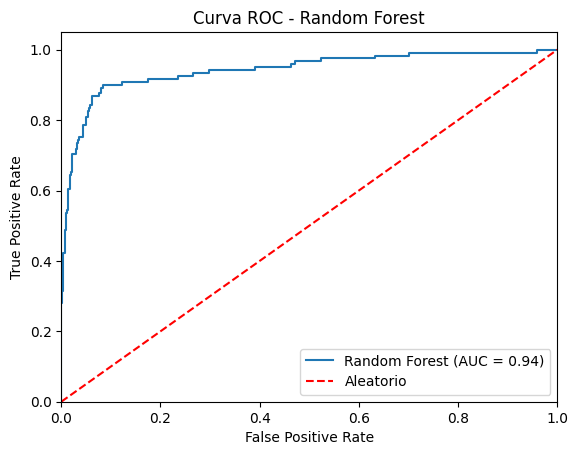

In [ ]:
# Curva ROC: representa la relación entre TPR y FPR a distintos umbrales
fpr, tpr, thresholds = roc_curve(y_test, pres_test[:, 1])
plt.figure()
plt.plot(fpr, tpr, label='Random Forest (AUC = %0.2f)' % roc_auc)
plt.plot([0, 1], [0, 1], 'r--', label='Aleatorio')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Curva ROC - Random Forest')
plt.legend(loc="lower right")
plt.show()

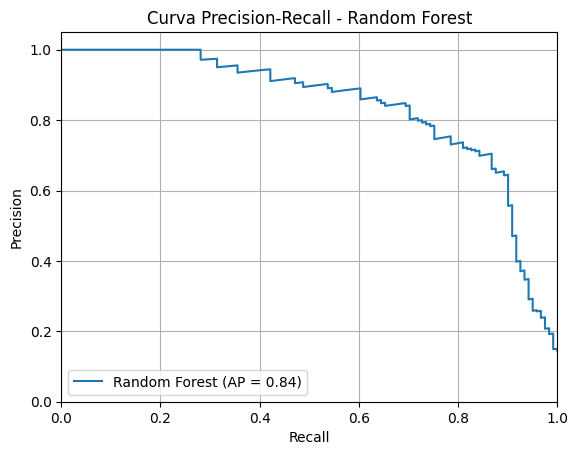

In [ ]:
# Curva Precision-Recall: útil cuando las clases están desbalanceadas
precision, recall, thresholds = precision_recall_curve(y_test, pres_test[:, 1])
average_precision = average_precision_score(y_test, pres_test[:, 1])

plt.figure()
plt.plot(recall, precision, label='Random Forest (AP = %0.2f)' % average_precision)
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Curva Precision-Recall - Random Forest')
plt.legend(loc="lower left")
plt.ylim([0.0, 1.05])
plt.xlim([0.0, 1.0])
plt.grid(True)
plt.show()

### 1.4.2 Ejercicio XGBoost

- Ajusta un xgboost y calcula el accuracy de tu modelo
- Utiliza el método predic_ proba para sacar la probabilidades de conversión de los usuarios
- Evalua con las diferentes métricas de evaluación

In [ ]:
# Calculamos el ratio de desbalanceo para XGBoost
# scale_pos_weight = n_negativos / n_positivos ~ 5.9
scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()
print(f"scale_pos_weight: {scale_pos_weight:.2f} (hay {scale_pos_weight:.1f}x más negativos que positivos)")

# Entrenamos XGBoost con scale_pos_weight para compensar el desbalanceo
xgboost = XGBClassifier(scale_pos_weight=scale_pos_weight)
xgboost.fit(X_train, y_train)

# Predicciones binarias y cálculo de accuracy
preds = xgboost.predict(X_test)
accuracy = (preds == y_test).sum().astype(float) / len(preds) * 100
print(f"XGBoost accuracy: {accuracy:.2f}%")

scale_pos_weight: 5.90 (hay 5.9x más negativos que positivos)
XGBoost accuracy: 96.16%


In [ ]:
# Probabilidades de pertenecer a cada clase (columna 0: no churn, columna 1: churn)
preds_p = xgboost.predict_proba(X_test)
preds_p

array([[0.99893975, 0.00106022],
       [0.9879019 , 0.01209807],
       [0.99701554, 0.00298448],
       ...,
       [0.99818057, 0.00181945],
       [0.98681843, 0.01318158],
       [0.9975871 , 0.00241292]], dtype=float32)

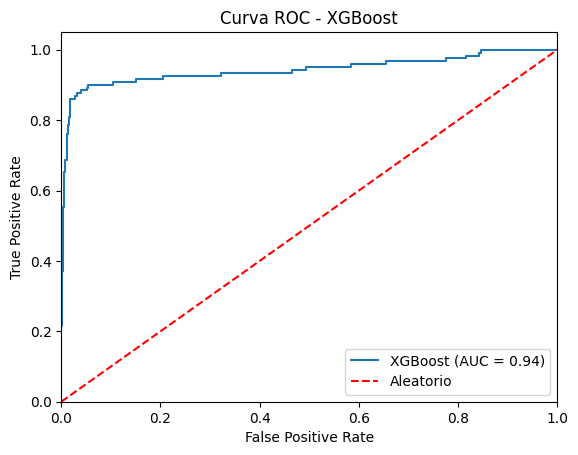

In [ ]:
# Curva ROC para XGBoost
fpr, tpr, thresholds = roc_curve(y_test, preds_p[:, 1])
xgb_auc = auc(fpr, tpr)

plt.figure()
plt.plot(fpr, tpr, label='XGBoost (AUC = %0.2f)' % xgb_auc)
plt.plot([0, 1], [0, 1], 'r--', label='Aleatorio')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Curva ROC - XGBoost')
plt.legend(loc="lower right")
plt.show()

In [ ]:
# AUC de XGBoost calculado con roc_auc_score (equivalente)
roc_auc = roc_auc_score(y_test, preds_p[:, 1])
print('XGBoost AUC:', roc_auc)

XGBoost AUC: 0.9425892225841225


# Ejercicio
- Selecciona a los 1000 usuarios con más probabilidad de churn
- Selecciona los usuarios con probabilidades de churn entre el 0.3 y 0.5
  - Realiza un EDA de estos usuarios. ¿Tienen algún patrón en común?


## Calibración de probabilidades

Comprobamos si las probabilidades predichas por los modelos están bien calibradas. Un modelo bien calibrado debería seguir la diagonal: si predice un 30% de probabilidad de churn, aproximadamente el 30% de esos usuarios debería hacer churn.

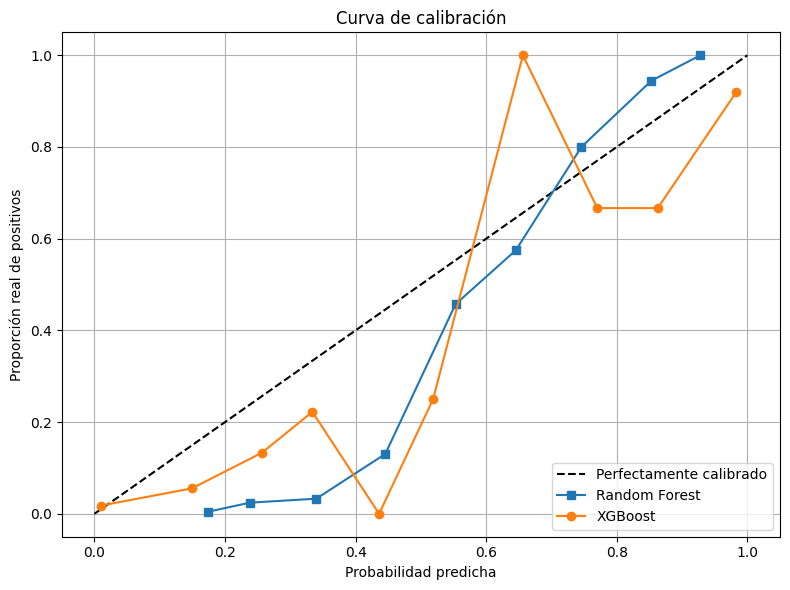

In [ ]:
# Curva de calibración: compara probabilidad predicha vs proporción real de positivos
fig, ax = plt.subplots(figsize=(8, 6))

# Línea de calibración perfecta (diagonal)
ax.plot([0, 1], [0, 1], 'k--', label='Perfectamente calibrado')

# Calibración del Random Forest
rf_prob_true, rf_prob_pred = calibration_curve(y_test, pres_test[:, 1], n_bins=10)
ax.plot(rf_prob_pred, rf_prob_true, 's-', label='Random Forest')

# Calibración del XGBoost
xgb_prob_true, xgb_prob_pred = calibration_curve(y_test, preds_p[:, 1], n_bins=10)
ax.plot(xgb_prob_pred, xgb_prob_true, 'o-', label='XGBoost')

ax.set_xlabel('Probabilidad predicha')
ax.set_ylabel('Proporción real de positivos')
ax.set_title('Curva de calibración')
ax.legend(loc='lower right')
ax.grid(True)
plt.tight_layout()
plt.show()

### Interpretación de la curva de calibración

Ninguno de los dos modelos está perfectamente calibrado:

- **Random Forest** tiende a comprimir las probabilidades hacia valores intermedios. Esto es un comportamiento típico de los ensembles basados en bagging: al promediar las predicciones de muchos árboles, las probabilidades extremas (cercanas a 0 o 1) se suavizan. Usar `class_weight='balanced'` ayuda a que el modelo no esté sesgado hacia la clase mayoritaria, produciendo probabilidades más dispersas y mejor calibradas.

- **XGBoost** suele estar mejor calibrado que Random Forest porque optimiza la log-loss directamente, pero con clases desbalanceadas puede desviarse. Usar `scale_pos_weight` corrige este sesgo penalizando más los errores en la clase minoritaria.

- **Efecto del desbalanceo en la calibración**: Sin corrección, los modelos tienden a predecir probabilidades bajas para todos (sesgados hacia la clase mayoritaria). Esto comprime la distribución de probabilidades y dificulta la calibración. Al balancear los pesos, las probabilidades se distribuyen mejor en el rango [0, 1].

Para refinar aún más, usamos `CalibratedClassifierCV` de scikit-learn, que ajusta las probabilidades mediante **Platt Scaling** (regresión logística sobre los scores) o **calibración isotónica** (ajuste no paramétrico). Aplicamos ambos métodos y comparamos el resultado.

In [ ]:
# Calibramos Random Forest con Platt Scaling (sigmoid) e Isotonic Regression
rf_sigmoid = CalibratedClassifierCV(rf_mod, method='sigmoid', cv=5)
rf_sigmoid.fit(X_train, y_train)
rf_sigmoid_probs = rf_sigmoid.predict_proba(X_test)[:, 1]

rf_isotonic = CalibratedClassifierCV(rf_mod, method='isotonic', cv=5)
rf_isotonic.fit(X_train, y_train)
rf_isotonic_probs = rf_isotonic.predict_proba(X_test)[:, 1]

# Calibramos XGBoost con Platt Scaling (sigmoid) e Isotonic Regression
xgb_sigmoid = CalibratedClassifierCV(xgboost, method='sigmoid', cv=5)
xgb_sigmoid.fit(X_train, y_train)
xgb_sigmoid_probs = xgb_sigmoid.predict_proba(X_test)[:, 1]

xgb_isotonic = CalibratedClassifierCV(xgboost, method='isotonic', cv=5)
xgb_isotonic.fit(X_train, y_train)
xgb_isotonic_probs = xgb_isotonic.predict_proba(X_test)[:, 1]

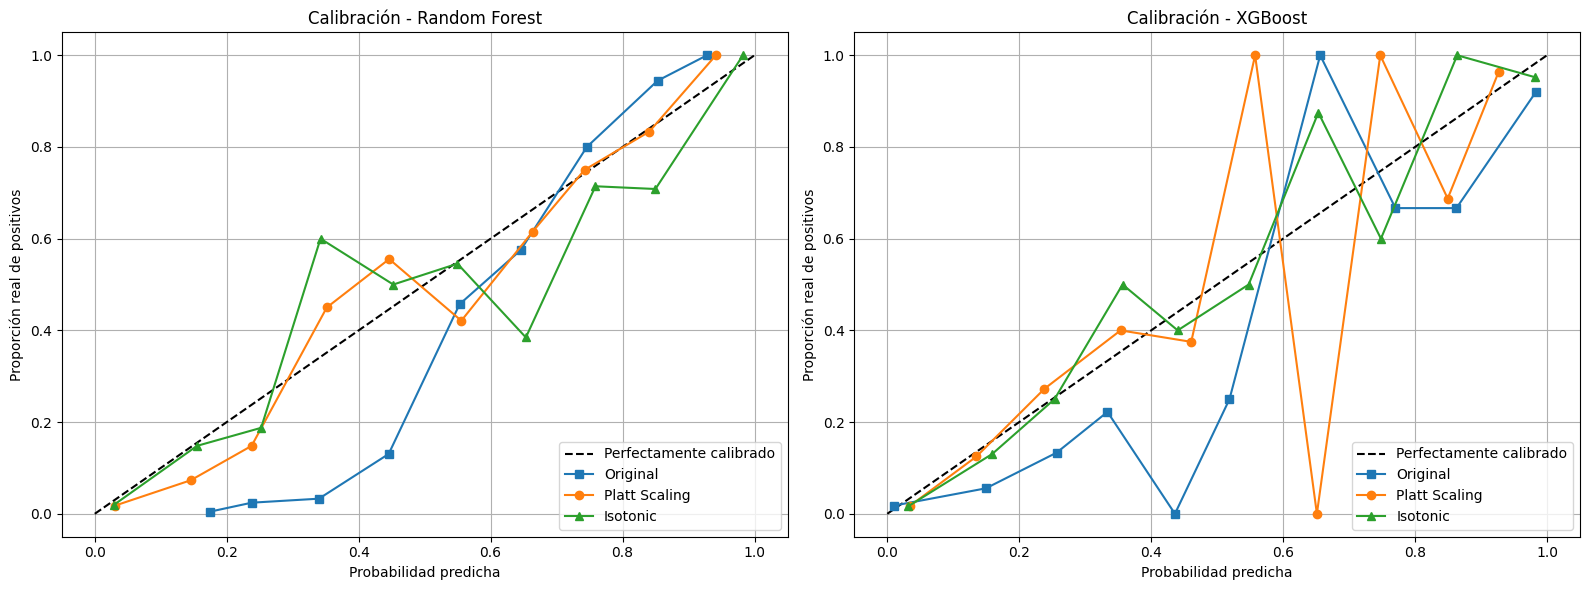

=== AUC antes y después de calibrar ===
RF Original:       0.9409
RF Platt Scaling:  0.9380
RF Isotonic:       0.9379

XGB Original:      0.9426
XGB Platt Scaling: 0.9421
XGB Isotonic:      0.9490


In [ ]:
# Comparamos las curvas de calibración antes y después de calibrar
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# --- Random Forest ---
ax = axes[0]
ax.plot([0, 1], [0, 1], 'k--', label='Perfectamente calibrado')

# Original
rf_orig_true, rf_orig_pred = calibration_curve(y_test, pres_test[:, 1], n_bins=10)
ax.plot(rf_orig_pred, rf_orig_true, 's-', label='Original')

# Platt Scaling
rf_sig_true, rf_sig_pred = calibration_curve(y_test, rf_sigmoid_probs, n_bins=10)
ax.plot(rf_sig_pred, rf_sig_true, 'o-', label='Platt Scaling')

# Isotonic
rf_iso_true, rf_iso_pred = calibration_curve(y_test, rf_isotonic_probs, n_bins=10)
ax.plot(rf_iso_pred, rf_iso_true, '^-', label='Isotonic')

ax.set_xlabel('Probabilidad predicha')
ax.set_ylabel('Proporción real de positivos')
ax.set_title('Calibración - Random Forest')
ax.legend(loc='lower right')
ax.grid(True)

# --- XGBoost ---
ax = axes[1]
ax.plot([0, 1], [0, 1], 'k--', label='Perfectamente calibrado')

# Original
xgb_orig_true, xgb_orig_pred = calibration_curve(y_test, preds_p[:, 1], n_bins=10)
ax.plot(xgb_orig_pred, xgb_orig_true, 's-', label='Original')

# Platt Scaling
xgb_sig_true, xgb_sig_pred = calibration_curve(y_test, xgb_sigmoid_probs, n_bins=10)
ax.plot(xgb_sig_pred, xgb_sig_true, 'o-', label='Platt Scaling')

# Isotonic
xgb_iso_true, xgb_iso_pred = calibration_curve(y_test, xgb_isotonic_probs, n_bins=10)
ax.plot(xgb_iso_pred, xgb_iso_true, '^-', label='Isotonic')

ax.set_xlabel('Probabilidad predicha')
ax.set_ylabel('Proporción real de positivos')
ax.set_title('Calibración - XGBoost')
ax.legend(loc='lower right')
ax.grid(True)

plt.tight_layout()
plt.show()

# AUC antes y después de calibrar
print("=== AUC antes y después de calibrar ===")
print(f"RF Original:       {roc_auc_score(y_test, pres_test[:, 1]):.4f}")
print(f"RF Platt Scaling:  {roc_auc_score(y_test, rf_sigmoid_probs):.4f}")
print(f"RF Isotonic:       {roc_auc_score(y_test, rf_isotonic_probs):.4f}")
print()
print(f"XGB Original:      {roc_auc_score(y_test, preds_p[:, 1]):.4f}")
print(f"XGB Platt Scaling: {roc_auc_score(y_test, xgb_sigmoid_probs):.4f}")
print(f"XGB Isotonic:      {roc_auc_score(y_test, xgb_isotonic_probs):.4f}")

## Interpretabilidad de los modelos

Entender **qué variables** impulsan las predicciones es tan importante como la precisión del modelo. Comparamos las feature importances de Random Forest (basada en reducción de impureza/Gini) y XGBoost (basada en ganancia) para identificar los drivers de churn.

Para árboles: Una feature es importante si separa bien las clases muchas veces y en nodos con muchos datos.

Para XGBoost: Cuánto mejora la pérdida al usar esa feature.

NameError: name 'xgboost' is not defined

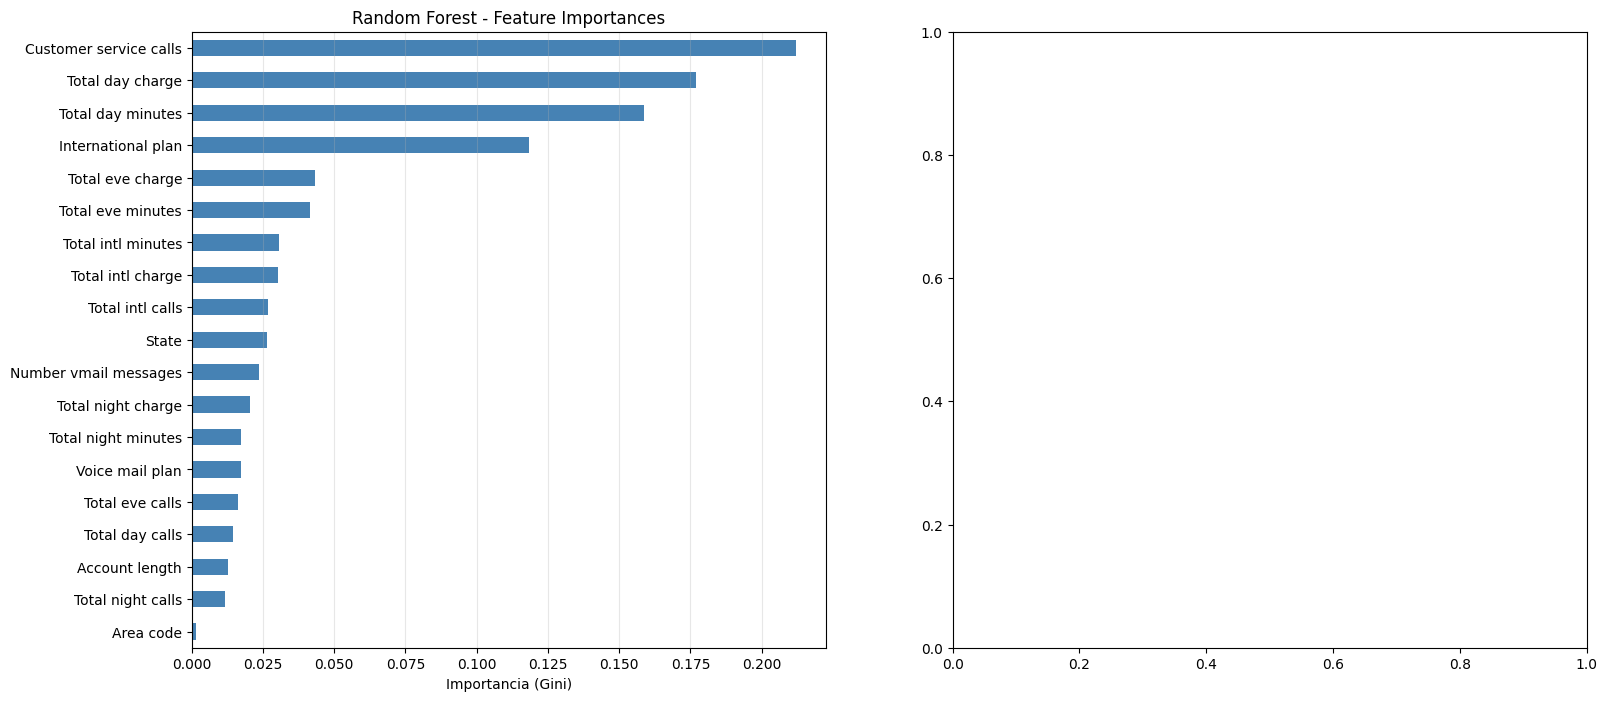

In [ ]:
#interesante
# Feature importances de ambos modelos
feature_names = X_train.columns

fig, axes = plt.subplots(1, 2, figsize=(18, 8))

# --- Random Forest ---
rf_importances = pd.Series(rf_mod.feature_importances_, index=feature_names).sort_values()
ax = axes[0]
rf_importances.plot(kind='barh', ax=ax, color='steelblue')
ax.set_xlabel('Importancia (Gini)')
ax.set_title('Random Forest - Feature Importances')
ax.grid(axis='x', alpha=0.3)

# --- XGBoost ---
xgb_importances = pd.Series(xgboost.feature_importances_, index=feature_names).sort_values()
ax = axes[1]
xgb_importances.plot(kind='barh', ax=ax, color='darkorange')
ax.set_xlabel('Importancia (Ganancia)')
ax.set_title('XGBoost - Feature Importances')
ax.grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.show()

# Top 5 features de cada modelo
print("=== Top 5 features ===\n")
print("Random Forest:")
for feat, imp in rf_importances.iloc[-5:][::-1].items():
    print(f"  {feat}: {imp:.4f}")
print()
print("XGBoost:")
for feat, imp in xgb_importances.iloc[-5:][::-1].items():
    print(f"  {feat}: {imp:.4f}")

Más adelante veréis otras librerías que permiten la interpretabilidad como SHAP

# CV - All together

- Logistic
- k-NN
- Random Forest
- xgboost



**Logistic Regression**

In [ ]:
# Logistic Regression con CV de 20 folds y múltiples métricas
random.seed(113)
LR = LogisticRegression()

scoring = ['accuracy', 'precision_macro', 'recall_macro', 'f1_weighted', 'roc_auc']
scores = cross_validate(LR, X_train, y_train, scoring=scoring, cv=20)

LR_fit_time = scores['fit_time'].mean()
LR_score_time = scores['score_time'].mean()
LR_accuracy = scores['test_accuracy'].mean()
LR_precision = scores['test_precision_macro'].mean()
LR_recall = scores['test_recall_macro'].mean()
LR_f1 = scores['test_f1_weighted'].mean()
LR_roc = scores['test_roc_auc'].mean()

In [ ]:
# AUC de cada fold de la Logistic Regression
print('Num folds:', scores['test_roc_auc'].shape[0])
scores['test_roc_auc']

Num folds: 20


array([0.75649013, 0.79543094, 0.68224299, 0.74662513, 0.60955348,
       0.87538941, 0.70560748, 0.73416407, 0.76998962, 0.76687435,
       0.7933541 , 0.80321911, 0.59916926, 0.62824507, 0.72897196,
       0.81100727, 0.68016615, 0.75322741, 0.65839126, 0.83805031])

**Random Forest**



In [ ]:
# Random Forest con CV de 20 folds
random_forest = RandomForestClassifier(random_state=random.seed(113))

scoring = ['accuracy', 'precision_macro', 'recall_macro', 'f1_weighted', 'roc_auc']
scores = cross_validate(random_forest, X_train, y_train, scoring=scoring, cv=20)

forest_fit_time = scores['fit_time'].mean()
forest_score_time = scores['score_time'].mean()
forest_accuracy = scores['test_accuracy'].mean()
forest_precision = scores['test_precision_macro'].mean()
forest_recall = scores['test_recall_macro'].mean()
forest_f1 = scores['test_f1_weighted'].mean()
forest_roc = scores['test_roc_auc'].mean()

In [ ]:
# AUC de cada fold deL Random Forest
print('Num folds:', scores['test_roc_auc'].shape[0])
scores['test_roc_auc']

Num folds: 20


array([0.78738318, 0.88369678, 0.93639668, 0.84164071, 0.95976116,
       0.95456906, 0.87954309, 0.93354102, 0.95612669, 0.94963655,
       0.99195223, 0.98727934, 0.84553479, 0.79387331, 0.87305296,
       0.95586708, 0.94496366, 0.8550149 , 0.6817279 , 0.96357442])

**k-NN**

In [ ]:
# k-NN con CV de 20 folds
random.seed(113)
KNN = KNeighborsClassifier()

scoring = ['accuracy', 'precision_macro', 'recall_macro', 'f1_weighted', 'roc_auc']
scores = cross_validate(KNN, X_train, y_train, scoring=scoring, cv=20)

KNN_fit_time = scores['fit_time'].mean()
KNN_score_time = scores['score_time'].mean()
KNN_accuracy = scores['test_accuracy'].mean()
KNN_precision = scores['test_precision_macro'].mean()
KNN_recall = scores['test_recall_macro'].mean()
KNN_f1 = scores['test_f1_weighted'].mean()
KNN_roc = scores['test_roc_auc'].mean()

In [ ]:
# AUC de cada fold del KNN
print('Num folds:', scores['test_roc_auc'].shape[0])
scores['test_roc_auc']

Num folds: 20


array([0.61838006, 0.653946  , 0.74896158, 0.66770509, 0.63343718,
       0.80555556, 0.63759086, 0.78634476, 0.66121495, 0.62123572,
       0.65212876, 0.68354102, 0.65628245, 0.53634476, 0.5046729 ,
       0.67341641, 0.70093458, 0.77110228, 0.56678252, 0.70702306])

**XGBoost**

In [ ]:
# XGBoost con CV de 5 folds (prueba rápida)
xgboost = XGBClassifier(use_label_encoder=False, eval_metric='logloss')

scoring = {'accuracy': 'accuracy', 'roc_auc': 'roc_auc'}

scores = cross_validate(
    estimator=xgboost,
    X=X_train,
    y=y_train,
    scoring=scoring,
    cv=5,
    return_train_score=True
)

print("Accuracy promedio:", scores['test_accuracy'].mean())
print("AUC promedio:", scores['test_roc_auc'].mean())

Accuracy promedio: 0.9515743486973948
AUC promedio: 0.9118650779908888


In [ ]:
# XGBoost con CV de 20 folds y todas las métricas
random.seed(113)
xgboost = XGBClassifier()

scoring = ['accuracy', 'precision_macro', 'recall_macro', 'f1_weighted', 'roc_auc']
scores = cross_validate(xgboost, X_train, y_train, scoring=scoring, cv=20)

XGB_fit_time = scores['fit_time'].mean()
XGB_score_time = scores['score_time'].mean()
XGB_accuracy = scores['test_accuracy'].mean()
XGB_precision = scores['test_precision_macro'].mean()
XGB_recall = scores['test_recall_macro'].mean()
XGB_f1 = scores['test_f1_weighted'].mean()
XGB_roc = scores['test_roc_auc'].mean()

**Comparamos todos los modelos**

In [ ]:
# Tabla comparativa de todos los modelos con CV
models_initial = pd.DataFrame({
    'Model'       : ['Logistic Regression', 'Random Forest', 'K-Nearest Neighbors', 'XGBoost'],
    'Fitting time': [LR_fit_time, forest_fit_time, KNN_fit_time, XGB_fit_time],
    'Scoring time': [LR_score_time, forest_score_time, KNN_score_time, XGB_score_time],
    'Accuracy'    : [LR_accuracy, forest_accuracy, KNN_accuracy, XGB_accuracy],
    'Precision'   : [LR_precision, forest_precision, KNN_precision, XGB_precision],
    'Recall'      : [LR_recall, forest_recall, KNN_recall, XGB_recall],
    'F1_score'    : [LR_f1, forest_f1, KNN_f1, XGB_f1],
    'AUC_ROC'     : [LR_roc, forest_roc, KNN_roc, XGB_roc],
}, columns=['Model', 'Fitting time', 'Scoring time', 'Accuracy', 'Precision', 'Recall', 'F1_score', 'AUC_ROC'])

models_initial.sort_values(by='Accuracy', ascending=False)

,Model,Fitting time,Scoring time,Accuracy,Precision,Recall,F1_score,AUC_ROC
3,XGBoost,0.359337,0.037826,0.951587,0.942107,0.858450,0.948462,0.907363
1,Random Forest,1.175971,0.055050,0.951184,0.951467,0.846885,0.947084,0.898757
2,K-Nearest Neighbors,0.005926,0.039770,0.869948,0.749354,0.607478,0.842015,0.664330
0,Logistic Regression,0.087926,0.025073,0.854335,0.655216,0.532581,0.806138,0.736808


In [ ]:
# Mejor AUC entre todos los modelos
print('Mejor AUC:', max(models_initial['AUC_ROC']))

Mejor AUC: 0.9073626231127692


**Buscamos los mejores hiperparámetros**

In [ ]:
# Definimos el modelo base de XGBoost para búsqueda de hiperparámetros
xgboost_base = XGBClassifier(random_state=101)

# Espacio de hiperparámetros para GridSearchCV
param_grid = {
    'max_depth': [3, 5, 7],
    'learning_rate': [0.01, 0.1, 0.2],
    'n_estimators': [50, 100, 200]
}

# GridSearchCV: prueba todas las combinaciones posibles
print("Iniciando GridSearchCV...")
grid_search = GridSearchCV(
    estimator=xgboost_base,
    param_grid=param_grid,
    scoring='roc_auc',
    cv=5,
    verbose=1
)
grid_search.fit(X_train, y_train)

print("\nMejores hiperparámetros (GridSearchCV):", grid_search.best_params_)
print("Mejor AUC (GridSearchCV):", grid_search.best_score_)

# Entrenamos modelo final con los mejores hiperparámetros
print("\nEntrenando el modelo final con los mejores hiperparámetros:", grid_search.best_params_)
final_xgboost = XGBClassifier(**grid_search.best_params_, random_state=101)
final_xgboost.fit(X_train, y_train)

# Evaluamos en test
y_pred_proba = final_xgboost.predict_proba(X_test)[:, 1]
roc_auc_test = roc_auc_score(y_test, y_pred_proba)
print("\nAUC en test (GridSearchCV):", roc_auc_test)

Iniciando GridSearchCV...
Fitting 5 folds for each of 27 candidates, totalling 135 fits

Mejores hiperparámetros (GridSearchCV): {'learning_rate': 0.1, 'max_depth': 7, 'n_estimators': 100}
Mejor AUC (GridSearchCV): 0.9139642301303637

Entrenando el modelo final con los mejores hiperparámetros: {'learning_rate': 0.1, 'max_depth': 7, 'n_estimators': 100}

AUC en test (GridSearchCV): 0.9475965829402015


In [ ]:
# Definimos el espacio de hiperparámetros para RandomizedSearchCV
param_dist = {
    'max_depth': [3, 5, 7, 9],
    'learning_rate': [0.01, 0.05, 0.1, 0.2],
    'n_estimators': [50, 100, 200, 300]
}

# RandomizedSearchCV
print("\nIniciando RandomizedSearchCV...")
random_search = RandomizedSearchCV(
    estimator=xgboost_base,
    param_distributions=param_dist,
    scoring='roc_auc',
    cv=5,
    verbose=1,
    n_iter=50,
    random_state=101,
)
random_search.fit(X_train, y_train)

print("\nMejores hiperparámetros (RandomizedSearchCV):", random_search.best_params_)# Mejores parámetros seleccionados utilizando la media de los folds
print("Mejor AUC (RandomizedSearchCV):", random_search.best_score_)

# Evaluamos el mejor modelo de RandomizedSearchCV en el conjunto de prueba
best_xgboost = random_search.best_estimator_ # Seleccionando los mejores parámetros es el estimador con mejor métrica dentro de los folds
y_pred_proba = best_xgboost.predict_proba(X_test)[:, 1]
roc_auc_test = roc_auc_score(y_test, y_pred_proba)
print("\nAUC en conjunto de prueba con mejores hiperparámetros (RandomizedSearchCV):", roc_auc_test)



Iniciando RandomizedSearchCV...
Fitting 5 folds for each of 50 candidates, totalling 250 fits

Mejores hiperparámetros (RandomizedSearchCV): {'n_estimators': 200, 'max_depth': 5, 'learning_rate': 0.05}
Mejor AUC (RandomizedSearchCV): 0.9219962850244368

AUC en conjunto de prueba con mejores hiperparámetros (RandomizedSearchCV): 0.8952642236592854


## Conclusión: ¿Qué métrica importa más en un problema de churn?

A lo largo de este notebook hemos evaluado los modelos con accuracy, precision, recall, F1-score, AUC-ROC. En un problema de churn, **no todas tienen la misma relevancia**:

- **Accuracy** es engañosa con datos desbalanceados. Un modelo que prediga "no churn" para todos los clientes alcanzaría un 85.5% de accuracy, pero sería completamente inútil para el negocio: no detectaría a ningún cliente a punto de irse.

- **Precision** nos dice qué proporción de los clientes que marcamos como churn realmente lo son. Es importante si las acciones de retención son costosas (ofertas agresivas, descuentos), porque un falso positivo supone gastar recursos en un cliente que no se iba a ir.

- **Recall** nos dice qué proporción de los clientes que realmente hacen churn logramos detectar. En churn, **esta suele ser la métrica más crítica**, porque el coste de perder un cliente (LTV perdido, coste de adquisición de uno nuevo) es generalmente mucho mayor que el coste de contactar a un cliente que no se iba a ir. Un falso negativo (cliente que hace churn sin ser detectado) es más caro que un falso positivo (contactar a un cliente leal por error).

- **AUC-ROC** es la mejor métrica para **comparar modelos entre sí** sin comprometerse con un umbral concreto. Mide la capacidad de discriminación global: qué tan bien separa el modelo a los clientes que harán churn de los que no. Es la métrica que hemos usado para seleccionar hiperparámetros y comparar Random Forest vs XGBoost.

- **Calibración** son fundamentales cuando necesitamos **usar las probabilidades directamente** para tomar decisiones (por ejemplo, priorizar llamadas de retención por probabilidad de churn, o calcular el valor esperado de una campaña). Un modelo con buen AUC pero mala calibración ordena bien a los clientes, pero miente sobre cuánto riesgo tiene cada uno.

**En la práctica**, la elección depende del caso de uso concreto:
- Si el objetivo es **generar una lista de clientes para contactar** y el coste de retención es bajo comparado con perder al cliente: priorizar **recall** (detectar el máximo número de churners, aunque algunos contactados sean falsos positivos).
- Si el objetivo es **comparar y seleccionar modelos**: usar **AUC-ROC**.
- Si el objetivo es **asignar probabilidades fiables** para calcular riesgo o valor esperado: verificar la calibración.
- Si los recursos de retención son muy limitados y solo podemos actuar sobre pocos clientes: equilibrar con **precision** o usar **F1-score** como compromiso.